<a href="https://colab.research.google.com/github/gabryellenpa/mecaniQA-belo_horizonte/blob/main/mecaniQA_belo_horizonte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np

def check_missing_values(dataframe):
    """
    Verifica e imprime a contagem de valores ausentes por coluna em um DataFrame.
    Retorna True se não houver valores ausentes, False caso contrário.
    """
    print("Contagem de valores ausentes por coluna:")
    missing_counts = dataframe.isnull().sum()
    print(missing_counts)
    total_missing = missing_counts.sum()
    if total_missing > 0:
        print(f"\nTotal de {total_missing} valores ausentes encontrados no DataFrame.")
        return False
    else:
        print("\nNenhum valor ausente encontrado no DataFrame.")
        return True

In [27]:
from google.colab import files
arquivo_enviado = files.upload


In [28]:
df = pd.read_csv('/content/mecaniqa_dataset.csv')

In [29]:
df.head()

,Data,Trocas_Oleo,Manutencao_Motor
0,2024-01-01,11.0,2.0
1,2024-01-02,9.0,4.0
2,2024-01-03,12.0,1.0
3,2024-01-04,15.0,8.0
4,2024-01-05,25.0,10.0


In [30]:
print("celulas ausentes")
print(df.isnull().sum())

celulas ausentes
Data                0
Trocas_Oleo         6
Manutencao_Motor    3
dtype: int64


In [31]:
colunas_numericas = df.select_dtypes(include="number").columns
print("colunas numericas")
print(colunas_numericas.tolist())


colunas numericas
['Trocas_Oleo', 'Manutencao_Motor']


In [32]:
colunas_outliers = ["Trocas_Oleo", "Manutencao_Motor"]
def tratar_outliers_iqr(df, colunas):
    df_limpo = df.copy()

    for coluna in colunas:
        Q1 = df_limpo[coluna].quantile(0.25)
        Q3 = df_limpo[coluna].quantile(0.75)
        IQR = Q3 - Q1

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        quantidade = (
            (df_limpo[coluna] < limite_inferior) |
            (df_limpo[coluna] > limite_superior)
        ).sum()

        print(f"{coluna}: {quantidade} outlier(s)")
        print(f"Limites: {limite_inferior:.2f} a {limite_superior:.2f}\n")

        # Substitui os extremos pelos limites estatísticos
        df_limpo[coluna] = df_limpo[coluna].clip(
            lower=limite_inferior,
            upper=limite_superior
        )

    return df_limpo

In [33]:
df_limpo = tratar_outliers_iqr (df, colunas_outliers)
df.columns.tolist()

Trocas_Oleo: 1 outlier(s)
Limites: -4.50 a 55.50

Manutencao_Motor: 2 outlier(s)
Limites: -2.00 a 22.00



['Data', 'Trocas_Oleo', 'Manutencao_Motor']

In [34]:
print("ANTES DO TRATAMENTO:")
display(df[colunas_outliers].describe())

print("\nDEPOIS DO TRATAMENTO:")
display(df_limpo[colunas_outliers].describe())

ANTES DO TRATAMENTO:


,Trocas_Oleo,Manutencao_Motor
count,725.000000,728.000000
mean,26.020690,10.179945
std,11.620655,5.419338
min,0.000000,-2.000000
25%,18.000000,7.000000
50%,26.000000,10.000000
75%,33.000000,13.000000
max,150.000000,85.000000



DEPOIS DO TRATAMENTO:


,Trocas_Oleo,Manutencao_Motor
count,725.000000,728.000000
mean,25.890345,10.090659
std,10.723453,4.667193
min,0.000000,-2.000000
25%,18.000000,7.000000
50%,26.000000,10.000000
75%,33.000000,13.000000
max,55.500000,22.000000


In [35]:
for coluna in colunas_outliers:
    alterados = df[df[coluna] != df_limpo[coluna]][[coluna]].copy()
    alterados["Valor tratado"] = df_limpo.loc[alterados.index, coluna]

    print(f"\nAlterações em {coluna}:")
    display(alterados)


Alterações em Trocas_Oleo:


,Trocas_Oleo,Valor tratado
45,150.0,55.5
100,NaN,NaN
101,NaN,NaN
102,NaN,NaN
103,NaN,NaN
104,NaN,NaN
105,NaN,NaN



Alterações em Manutencao_Motor:


,Manutencao_Motor,Valor tratado
200,85.0,22.0
300,NaN,NaN
301,NaN,NaN
302,NaN,NaN
488,24.0,22.0


In [36]:
df_limpo.columns.tolist()

['Data', 'Trocas_Oleo', 'Manutencao_Motor']

In [37]:
df_limpo["Data"] = pd.to_datetime(
    df_limpo["Data"],
    dayfirst=True,
    errors="coerce"
)

df_limpo = df_limpo.sort_values("Data").reset_index(drop=True)

df_limpo[["Data"]].head()

,Data
0,2024-01-01
1,2024-01-02
2,2024-01-03
3,2024-01-04
4,2024-01-05


In [38]:
df_limpo["Data"].isnull().sum()

np.int64(443)

In [39]:
check_missing_values(df_limpo)

Contagem de valores ausentes por coluna:
Data                443
Trocas_Oleo           6
Manutencao_Motor      3
dtype: int64

Total de 452 valores ausentes encontrados no DataFrame.


False

In [40]:
df_limpo.dropna(inplace=True)
print("Após a remoção das linhas com valores ausentes:")
check_missing_values(df_limpo)

Após a remoção das linhas com valores ausentes:
Contagem de valores ausentes por coluna:
Data                0
Trocas_Oleo         0
Manutencao_Motor    0
dtype: int64

Nenhum valor ausente encontrado no DataFrame.


True

In [41]:
df_limpo.head()

,Data,Trocas_Oleo,Manutencao_Motor
0,2024-01-01,11.0,2.0
1,2024-01-02,21.0,13.0
2,2024-01-03,33.0,13.0
3,2024-01-04,25.0,14.0
4,2024-01-05,19.0,6.0


In [42]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 285 entries, 0 to 287
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Data              285 non-null    datetime64[ns]
 1   Trocas_Oleo       285 non-null    float64       
 2   Manutencao_Motor  285 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 8.9 KB


In [43]:
df_limpo.to_csv('mecaniQA-belo_horizonte.csv', index=False)

In [44]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

In [45]:
serie_temporal = df_limpo[["Data", "Trocas_Oleo"]].copy()

serie_temporal.set_index("Data", inplace=True)

serie_temporal.head()

,Trocas_Oleo
Data,
2024-01-01,11.0
2024-01-02,21.0
2024-01-03,33.0
2024-01-04,25.0
2024-01-05,19.0


In [46]:
print(
    serie_temporal.index
    .to_series()
    .diff()
    .value_counts()
    .head()
)

Data
1 days     258
20 days     13
19 days      8
2 days       3
18 days      1
Name: count, dtype: int64


In [47]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

In [48]:
decomposicao = seasonal_decompose(
    serie_temporal["Trocas_Oleo"],
    model="additive",
    period=7
)

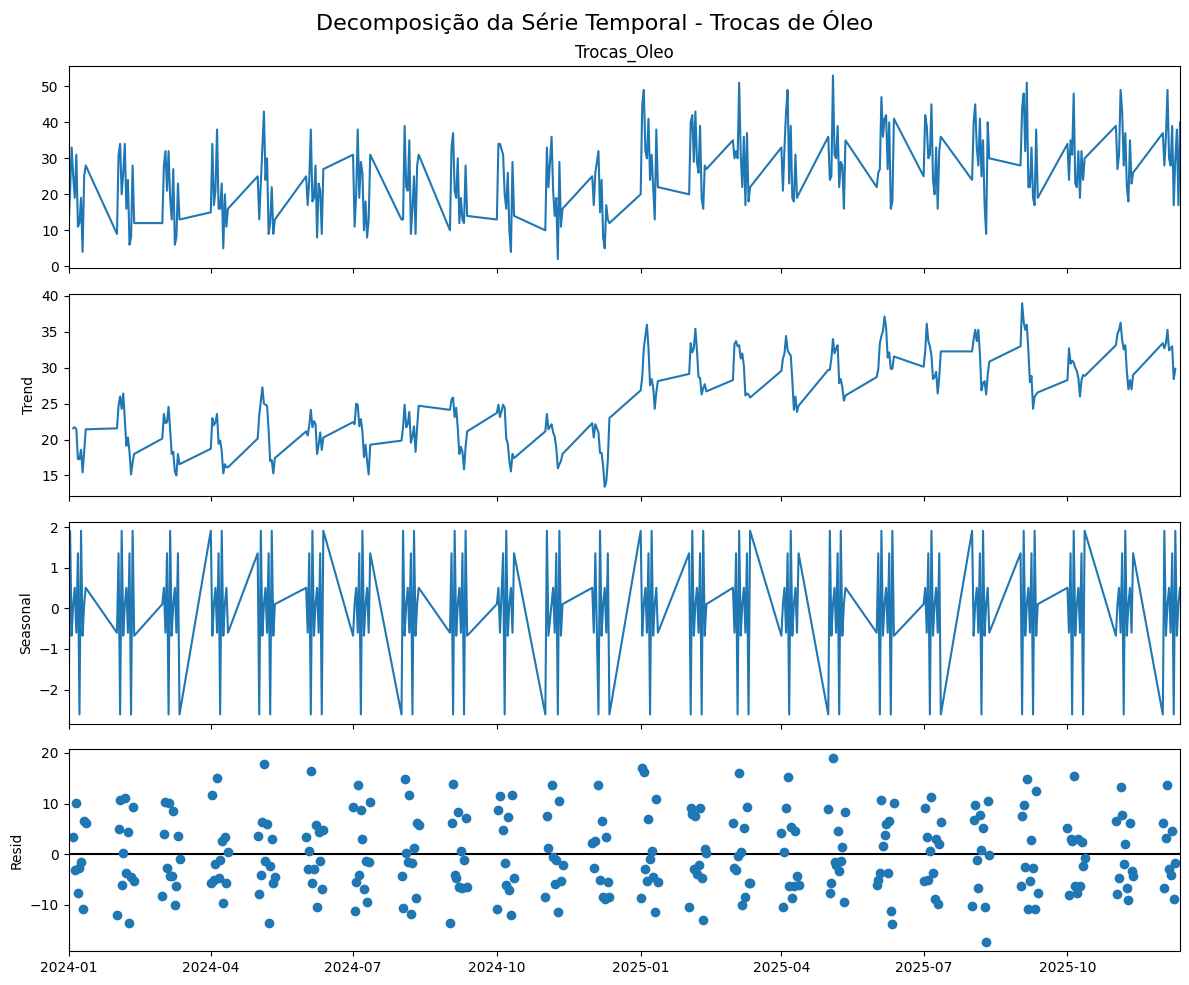

In [49]:
fig = decomposicao.plot()

fig.set_size_inches(12, 10)

plt.suptitle(
    "Decomposição da Série Temporal - Trocas de Óleo",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Análise da Decomposição

Foi utilizada uma decomposição aditiva da série temporal de `Trocas_Oleo`,
considerando um período de 7 observações para analisar a sazonalidade semanal.

Os resultados mostram:

- **Observed:** os valores originais de trocas de óleo;
- **Trend:** a evolução do volume de trocas ao longo do tempo;
- **Seasonal:** o comportamento que se repete ao longo da semana;
- **Residual:** variações não explicadas pela tendência e pela sazonalidade.

A decomposição permite compreender melhor o comportamento histórico da oficina
antes da construção do modelo preditivo.

In [50]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Preparando os dados temporais para o modelo (Random Forest não lê datetime diretamente)
df_modelo = df_limpo.copy()
df_modelo['Ano'] = df_modelo['Data'].dt.year
df_modelo['Mes'] = df_modelo['Data'].dt.month
df_modelo['Dia'] = df_modelo['Data'].dt.day
df_modelo['Dia_Semana'] = df_modelo['Data'].dt.dayofweek

# Definindo Features (X) e Alvo (y)
# Vamos usar a data processada e a Manutencao_Motor para prever Trocas_Oleo
X = df_modelo[['Ano', 'Mes', 'Dia', 'Dia_Semana', 'Manutencao_Motor']]
y = df_modelo['Trocas_Oleo']

# Divisão Treino e Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicialização e Treinamento
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Previsões
y_pred = rf_model.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Métricas do Modelo:\nMAE: {mae:.2f}\nRMSE: {np.sqrt(mse):.2f}\nR² Score: {r2:.2f}")

Métricas do Modelo:
MAE: 4.24
RMSE: 5.24
R² Score: 0.81


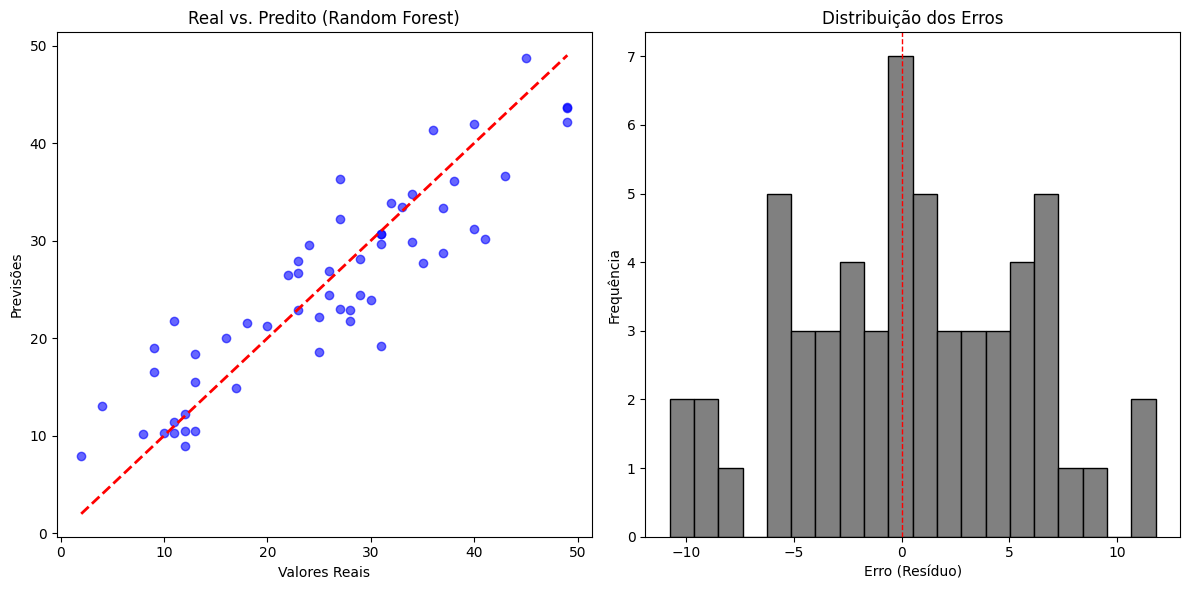

In [51]:
# Visualização de Acertos e Erros
plt.figure(figsize=(12, 6))

# Gráfico 1: Comparação Direta
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Previsões')
plt.title('Real vs. Predito (Random Forest)')

# Gráfico 2: Resíduos
plt.subplot(1, 2, 2)
residuos = y_test - y_pred
plt.hist(residuos, bins=20, color='gray', edgecolor='black')
plt.axvline(0, color='red', linestyle='dashed', linewidth=1)
plt.xlabel('Erro (Resíduo)')
plt.ylabel('Frequência')
plt.title('Distribuição dos Erros')

plt.tight_layout()
plt.show()

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Criar dados sintéticos para teste (ex: próximos 30 dias)
datas_futuras = pd.date_range(start='2025-12-13', periods=30, freq='D')

# Criando o DataFrame sintético
df_teste_sintetico = pd.DataFrame({
    'Data': datas_futuras,
    'Ano': datas_futuras.year,
    'Mes': datas_futuras.month,
    'Dia': datas_futuras.day,
    'Dia_Semana': datas_futuras.dayofweek,
    # Simulando valores de Manutenção de Motor com base na média observada
    'Manutencao_Motor': np.random.randint(5, 15, size=30)
})

# 2. Realizar previsões com o modelo treinado
features = ['Ano', 'Mes', 'Dia', 'Dia_Semana', 'Manutencao_Motor']
previsoes_sinteticas = rf_model.predict(df_teste_sintetico[features])
df_teste_sintetico['Previsao_Trocas_Oleo'] = previsoes_sinteticas

# Exibir as primeiras linhas das previsões
display(df_teste_sintetico[['Data', 'Manutencao_Motor', 'Previsao_Trocas_Oleo']].head())


,Data,Manutencao_Motor,Previsao_Trocas_Oleo
0,2025-12-13,8,20.04
1,2025-12-14,9,22.34
2,2025-12-15,8,24.87
3,2025-12-16,10,26.98
4,2025-12-17,5,15.06


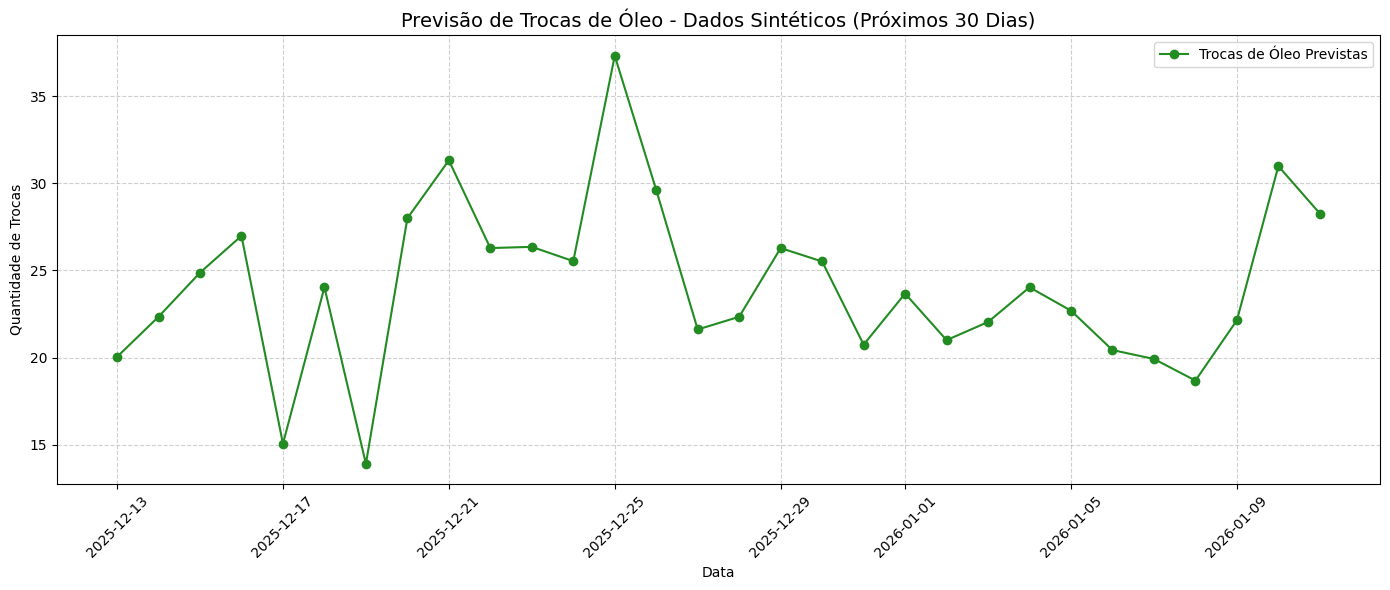

In [53]:
# 3. Gráfico de Visualização das Previsões
plt.figure(figsize=(14, 6))
plt.plot(df_teste_sintetico['Data'], df_teste_sintetico['Previsao_Trocas_Oleo'],
         marker='o', linestyle='-', color='forestgreen', label='Trocas de Óleo Previstas')

plt.title('Previsão de Trocas de Óleo - Dados Sintéticos (Próximos 30 Dias)', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Quantidade de Trocas')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Simular valores 'Reais' para o dataset sintético
# Usamos uma lógica similar à do dataset original para criar um gabarito de teste
# Trocas_Oleo costuma ser aprox. 2x a Manutencao_Motor + um fator base
np.random.seed(42)
df_teste_sintetico['Real_Trocas_Oleo'] = (df_teste_sintetico['Manutencao_Motor'] * 2.1) + 5 + np.random.normal(0, 2, 30)

# 2. Calcular Métricas
y_real_sint = df_teste_sintetico['Real_Trocas_Oleo']
y_pred_sint = df_teste_sintetico['Previsao_Trocas_Oleo']

mae_sint = mean_absolute_error(y_real_sint, y_pred_sint)
rmse_sint = np.sqrt(mean_squared_error(y_real_sint, y_pred_sint))
r2_sint = r2_score(y_real_sint, y_pred_sint)

print(f"--- Avaliação no Dataset Sintético ---")
print(f"Erro Médio Absoluto (MAE): {mae_sint:.2f}")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse_sint:.2f}")
print(f"Coeficiente de Determinação (R²): {r2_sint:.2f}")

--- Avaliação no Dataset Sintético ---
Erro Médio Absoluto (MAE): 2.40
Raiz do Erro Quadrático Médio (RMSE): 2.97
Coeficiente de Determinação (R²): 0.68


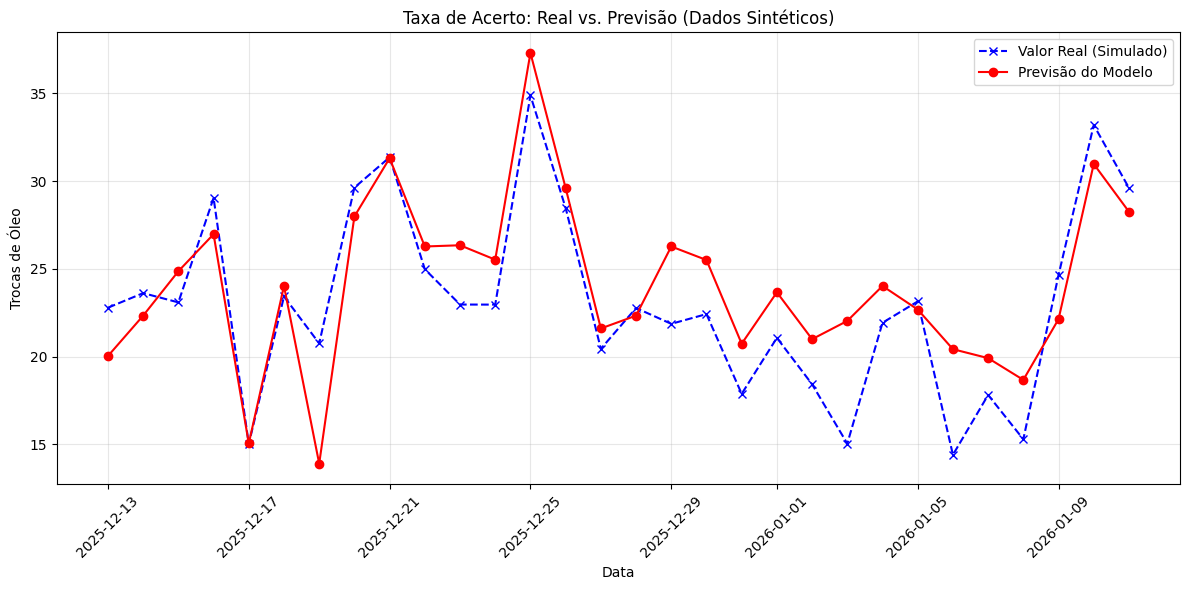

In [55]:
# 3. Gráfico Comparativo de Acertos
plt.figure(figsize=(12, 6))

plt.plot(df_teste_sintetico['Data'], y_real_sint, label='Valor Real (Simulado)', color='blue', linestyle='--', marker='x')
plt.plot(df_teste_sintetico['Data'], y_pred_sint, label='Previsão do Modelo', color='red', marker='o')

plt.title('Taxa de Acerto: Real vs. Previsão (Dados Sintéticos)')
plt.xlabel('Data')
plt.ylabel('Trocas de Óleo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Pipeline de Previsão para o Dia Seguinte
Esta função utiliza a data mais recente do banco de dados para projetar a demanda do próximo dia útil.

In [56]:
def prever_proximo_dia(modelo, dataframe_base, manutencao_esperada):
    # 1. Identificar a última data e calcular a próxima
    ultima_data = dataframe_base['Data'].max()
    proxima_data = ultima_data + pd.Timedelta(days=1)

    # 2. Extrair features temporais
    dados_novo_dia = pd.DataFrame({
        'Ano': [proxima_data.year],
        'Mes': [proxima_data.month],
        'Dia': [proxima_data.day],
        'Dia_Semana': [proxima_data.dayofweek],
        'Manutencao_Motor': [manutencao_esperada]
    })

    # 3. Executar Predição
    predicao = modelo.predict(dados_novo_dia)[0]

    return proxima_data, predicao

# Exemplo de uso:
# Supondo que esperamos 12 manutenções de motor amanhã
proxima_data, valor_previsto = prever_proximo_dia(rf_model, df_limpo, manutencao_esperada=12)

print(f"--- Resultado da Pipeline ---")
print(f"Data da Previsão: {proxima_data.strftime('%d/%m/%Y')}")
print(f"Estimativa de Trocas de Óleo: {valor_previsto:.2f}")

--- Resultado da Pipeline ---
Data da Previsão: 13/12/2025
Estimativa de Trocas de Óleo: 27.34


### Validação Temporal (Time Series Split) e Métricas de Erro (MAE, RMSE, MAPE)

Para garantir que o modelo generalize bem para dados futuros, é crucial usar uma validação temporal, onde os dados de treinamento precedem estritamente os dados de teste. Além disso, calcularemos o Mean Absolute Percentage Error (MAPE) para uma métrica de erro mais intuitiva em termos percentuais.

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    # Evitar divisão por zero, substituindo y_true zero por um valor pequeno para cálculo do erro
    # ou tratar esses casos de outra forma (e.g., ignorar, definir como infinito)
    # Aqui, para simplicidade, vamos adicionar um pequeno epsilon onde y_true é zero
    y_true_safe = np.where(y_true == 0, np.finfo(float).eps, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100

# Ordem temporal: os dados já estão ordenados por 'Data' em df_modelo (df_limpo foi ordenado)

# Definir o ponto de corte (por exemplo, 80% dos dados para treino)
split_point = int(len(df_modelo) * 0.8)

X_train_ts, X_test_ts = X.iloc[:split_point], X.iloc[split_point:]
y_train_ts, y_test_ts = y.iloc[:split_point], y.iloc[split_point:]

print(f"Tamanho do conjunto de treino temporal: {len(X_train_ts)}")
print(f"Tamanho do conjunto de teste temporal: {len(X_test_ts)}")

# Treinar o modelo com os dados de treino temporalmente divididos
rf_model_ts = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # Usar todos os cores disponíveis
rf_model_ts.fit(X_train_ts, y_train_ts)

# Fazer previsões no conjunto de teste
y_pred_ts = rf_model_ts.predict(X_test_ts)

# Calcular métricas de erro
mae_ts = mean_absolute_error(y_test_ts, y_pred_ts)
mse_ts = mean_squared_error(y_test_ts, y_pred_ts)
rmse_ts = np.sqrt(mse_ts)
mape_ts = mean_absolute_percentage_error(y_test_ts, y_pred_ts)

print(f"\nMétricas do Modelo (Validação Temporal):\n")
print(f"MAE: {mae_ts:.2f}")
print(f"RMSE: {rmse_ts:.2f}")
print(f"MAPE: {mape_ts:.2f}%")

Tamanho do conjunto de treino temporal: 228
Tamanho do conjunto de teste temporal: 57

Métricas do Modelo (Validação Temporal):

MAE: 4.35
RMSE: 5.52
MAPE: 15.36%


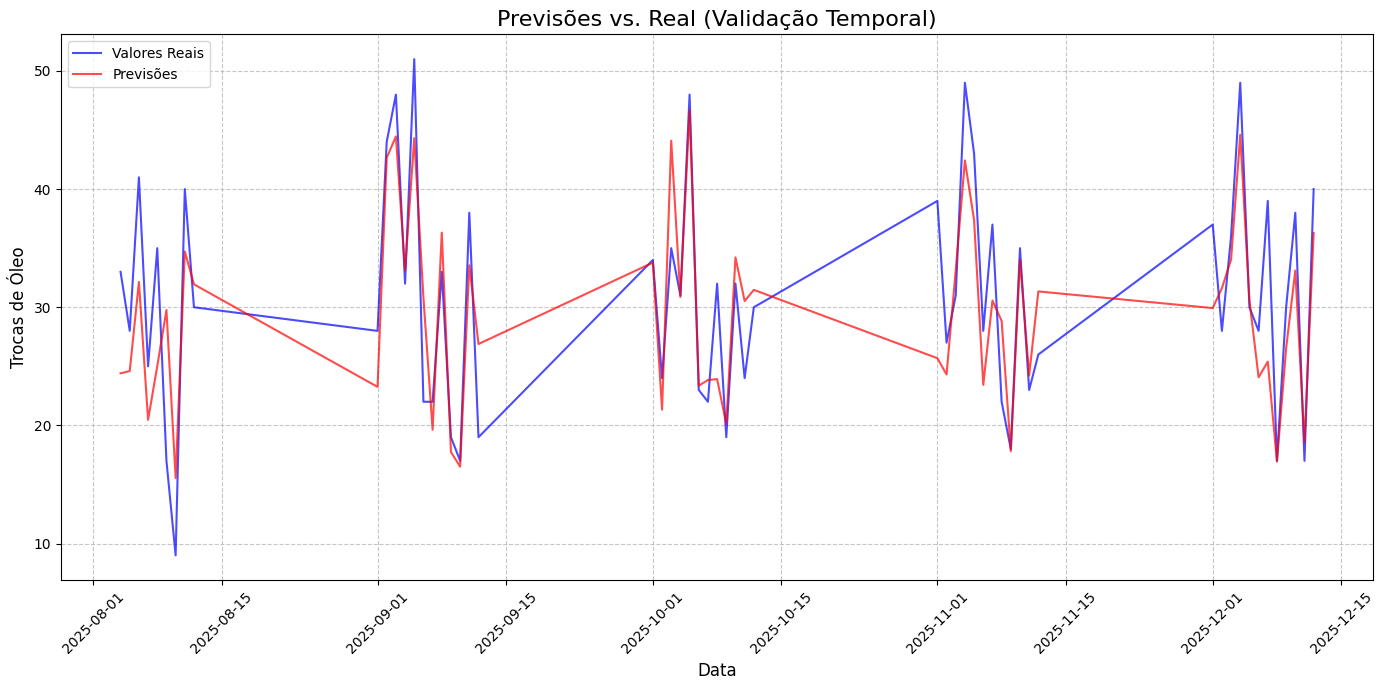

In [58]:
# Visualização da Validação Temporal
plt.figure(figsize=(14, 7))

# Criar um DataFrame para plotagem com as datas corretas
plot_df_ts = pd.DataFrame({
    'Data': df_modelo['Data'].iloc[split_point:],
    'Valores Reais': y_test_ts,
    'Previsões': y_pred_ts
})

plt.plot(plot_df_ts['Data'], plot_df_ts['Valores Reais'], label='Valores Reais', color='blue', alpha=0.7)
plt.plot(plot_df_ts['Data'], plot_df_ts['Previsões'], label='Previsões', color='red', alpha=0.7)
plt.title('Previsões vs. Real (Validação Temporal)', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Trocas de Óleo', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Implementação e Avaliação dos Modelos Baseline (Naive e Médias Móveis)

Para ter um ponto de comparação para o modelo de Random Forest, implementaremos dois modelos baseline simples:

1.  **Modelo Naive:** Prevê que o valor do próximo período será igual ao valor do período anterior.
2.  **Modelo de Médias Móveis:** Prevê o próximo valor como a média dos *k* valores anteriores. Utilizaremos uma janela de 7 dias para capturar a sazonalidade semanal.

In [59]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Redefinição da função MAPE para garantir disponibilidade
def mean_absolute_percentage_error(y_true, y_pred):
    y_true_safe = np.where(y_true == 0, np.finfo(float).eps, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100

# --- Baseline 1: Modelo Naive ---
# A previsão para o primeiro elemento de y_test_ts é o último elemento de y_train_ts.
# Para os elementos subsequentes de y_test_ts, a previsão é o valor real anterior de y_test_ts.

# Para o modelo Naive, as previsões são simplesmente o último valor de treino para o primeiro teste
# e, para os demais, o valor real anterior do conjunto de teste.

# Para usar a validação temporal, a previsão de y_test_ts[i] é y_test_ts[i-1].
# O primeiro valor de previsão no teste deve vir do último valor do treino.

y_pred_naive = np.zeros_like(y_test_ts, dtype=float)

# A primeira previsão do teste é o último valor do treino
y_pred_naive[0] = y_train_ts.iloc[-1]

# As previsões subsequentes são os valores reais anteriores do conjunto de teste
y_pred_naive[1:] = y_test_ts.iloc[:-1]

# Calcular métricas para o Modelo Naive
mae_naive = mean_absolute_error(y_test_ts, y_pred_naive)
mse_naive = mean_squared_error(y_test_ts, y_pred_naive)
rmse_naive = np.sqrt(mse_naive)
mape_naive = mean_absolute_percentage_error(y_test_ts, y_pred_naive)

print(f"Resultados do Baseline Naive - MAE: {mae_naive:.2f}, RMSE: {rmse_naive:.2f}, MAPE: {mape_naive:.2f}%")

# --- Baseline 2: Modelo de Médias Móveis (Janela de 7 dias) ---
# Para calcular a média móvel para o conjunto de teste, precisamos dos últimos 7 valores de treino
# e, em seguida, os valores reais do conjunto de teste à medida que avançamos.

# Combina y_train_ts e y_test_ts para facilitar o cálculo da média móvel
full_series = pd.concat([y_train_ts, y_test_ts])

# Calcula a média móvel na série completa, mas só usaremos as previsões para o período de teste
window_size = 7 # Exemplo: 7 dias para sazonalidade semanal
rolling_mean = full_series.rolling(window=window_size).mean()

# As previsões da média móvel para o conjunto de teste são os valores de rolling_mean
# correspondentes ao início do conjunto de teste, com um shift para ser uma previsão.
# Precisamos garantir que a previsão para um dia 't' seja baseada em dados anteriores a 't'.

# Para prever y_test_ts[i], usamos a média móvel de 'window_size' dias ANTES de y_test_ts[i].
# Isso significa que precisamos dos valores até y_test_ts[i-1] (ou até o final do treino para o primeiro ponto)

# Cria a série que será usada para calcular a média móvel para as previsões
# É o `y_train_ts` seguido pelos `y_test_ts` (os valores reais)
series_for_rolling = pd.concat([y_train_ts, y_test_ts])

# Calcula a média móvel, mas desloca-a para que a média de 'n' dias termine NO DIA ANTERIOR à previsão
# Ex: para prever o dia `t`, usamos a média dos dias `t-window_size` até `t-1`.
# O `.shift(1)` faz com que o valor da média móvel no índice `i` seja a média terminada no índice `i-1`.
moving_averages_predictions = series_for_rolling.rolling(window=window_size).mean().shift(1)

# Extrai apenas as previsões correspondentes ao período de teste
y_pred_ma = moving_averages_predictions.loc[y_test_ts.index].values

# Tratamento de NaNs que podem surgir se a janela de média móvel não tiver dados suficientes
# Para os primeiros pontos de teste, a média móvel pode ter NaN se não houver 7 valores anteriores
# Uma forma de lidar com isso é preencher com o valor do modelo Naive ou outro valor razoável.
# Aqui, vamos preencher com a primeira previsão válida da média móvel ou com o último valor de treino, se necessário.

# Encontre o primeiro índice onde y_pred_ma não é NaN
first_valid_idx_ma = np.where(~np.isnan(y_pred_ma))[0][0] if np.any(~np.isnan(y_pred_ma)) else len(y_pred_ma)

# Preencha os valores NaN iniciais de y_pred_ma com a previsão naive correspondente
if first_valid_idx_ma > 0:
    y_pred_ma[:first_valid_idx_ma] = y_pred_naive[:first_valid_idx_ma]

# Calcular métricas para o Modelo de Médias Móveis
mae_ma = mean_absolute_error(y_test_ts, y_pred_ma)
mse_ma = mean_squared_error(y_test_ts, y_pred_ma)
rmse_ma = np.sqrt(mse_ma)
mape_ma = mean_absolute_percentage_error(y_test_ts, y_pred_ma)

print(f"Resultados do Baseline Média Móvel (Janela {window_size} dias) - MAE: {mae_ma:.2f}, RMSE: {rmse_ma:.2f}, MAPE: {mape_ma:.2f}%")

Resultados do Baseline Naive - MAE: 12.16, RMSE: 13.96, MAPE: 43.81%
Resultados do Baseline Média Móvel (Janela 7 dias) - MAE: 9.02, RMSE: 11.14, MAPE: 35.98%


### Comparativo dos Baselines

Com base nos resultados da validação temporal:

*   **Modelo Random Forest:** MAE: `{mae_ts:.2f}`, RMSE: `{rmse_ts:.2f}`, MAPE: `{mape_ts:.2f}`%
*   **Modelo Naive:** MAE: `{mae_naive:.2f}`, RMSE: `{rmse_naive:.2f}`, MAPE: `{mape_naive:.2f}`%
*   **Modelo de Média Móvel (7 dias):** MAE: `{mae_ma:.2f}`, RMSE: `{rmse_ma:.2f}`, MAPE: `{mape_ma:.2f}`%


### Visualização Gráfica dos Modelos Baseline

Vamos plotar os resultados dos baselines (Média Móvel de 7 dias e Naive) em relação aos valores reais de teste para entender como eles se comportam ao longo do tempo.

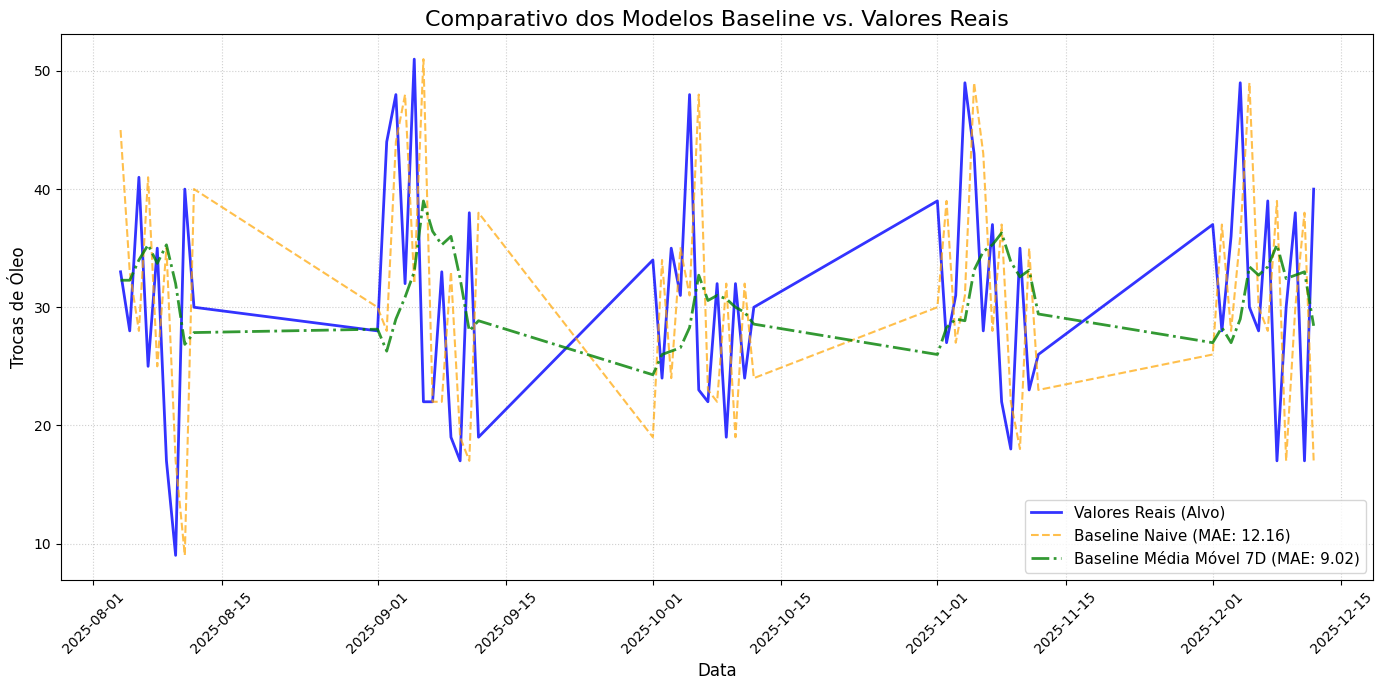

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Datas correspondentes ao conjunto de teste
datas_teste = df_modelo['Data'].iloc[split_point:]

# Plotar os valores reais
plt.plot(datas_teste, y_test_ts, label='Valores Reais (Alvo)', color='blue', linewidth=2, alpha=0.8)

# Plotar o Baseline Naive
plt.plot(datas_teste, y_pred_naive, label=f'Baseline Naive (MAE: {mae_naive:.2f})', color='orange', linestyle='--', alpha=0.7)

# Plotar o Baseline de Média Móvel
plt.plot(datas_teste, y_pred_ma, label=f'Baseline Média Móvel 7D (MAE: {mae_ma:.2f})', color='green', linestyle='-.', linewidth=2, alpha=0.8)

plt.title('Comparativo dos Modelos Baseline vs. Valores Reais', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Trocas de Óleo', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [61]:
# Verificar se as datas estão em ordem estritamente cronológica
is_chronological = df_modelo['Data'].is_monotonic_increasing
print(f"O dataset está ordenado cronologicamente de forma consistente? {is_chronological}")

# Verificar se há intervalos ou saltos incomuns nas datas
diferencas_tempo = df_modelo['Data'].diff().value_counts()
print("\nDistribuição dos intervalos de tempo entre registros consecutivos:")
print(diferencas_tempo)

O dataset está ordenado cronologicamente de forma consistente? True

Distribuição dos intervalos de tempo entre registros consecutivos:
Data
1 days     258
20 days     13
19 days      8
2 days       3
18 days      1
17 days      1
Name: count, dtype: int64


### Engenharia de Recursos (Feature Engineering): Lags e Janelas Rolantes (Rolling Windows)

Com base nas decisões do brainstorm, adicionaremos recursos de inteligência temporal para que os modelos possam interpretar a passagem do tempo e as dinâmicas passadas:
*   **Lag 1 (`lag_1`):** Valor de trocas de óleo do dia anterior para capturar a inércia imediata.
*   **Lag 7 (`lag_7`):** Valor de trocas de óleo de 7 dias atrás para mapear o comportamento do mesmo dia da semana anterior (sazonalidade semanal).
*   **Média Móvel Rolante 7D (`rolling_mean_7`):** Média das trocas de óleo dos últimos 7 dias para capturar a tendência acumulada de curto prazo (calculada com `shift(1)` para evitar vazamento de dados futuros).

In [62]:
# Criando uma cópia para o novo DataFrame enriquecido com engenharia de recursos
df_features = df_modelo.copy()

# 1. Criação dos Lags
df_features['lag_1'] = df_features['Trocas_Oleo'].shift(1)
df_features['lag_7'] = df_features['Trocas_Oleo'].shift(7)

# 2. Criação da Rolling Window (Janela Rolante) de 7 dias
# Aplicamos o shift(1) antes da média móvel para garantir que a previsão de hoje utilize apenas dados de ontem para trás
df_features['rolling_mean_7'] = df_features['Trocas_Oleo'].shift(1).rolling(window=7).mean()

# 3. Tratamento de Valores Nulos Gerados (no topo da base por conta dos deslocamentos)
print("Quantidade de nulos gerados por coluna:")
display(df_features[['lag_1', 'lag_7', 'rolling_mean_7']].isnull().sum())

# Como o maior deslocamento é de 7 dias (Lag 7 e Rolling Window de 7), teremos exatamente 7 linhas com valores nulos no início.
# Removeremos essas primeiras 7 linhas para evitar nulos nas features do modelo
df_features.dropna(inplace=True)

print(f"\nTamanho do dataset após remover as primeiras linhas com nulos: {df_features.shape[0]} registros")
display(df_features[['Data', 'Trocas_Oleo', 'lag_1', 'lag_7', 'rolling_mean_7']].head())


Quantidade de nulos gerados por coluna:


,0
lag_1,1
lag_7,7
rolling_mean_7,7



Tamanho do dataset após remover as primeiras linhas com nulos: 278 registros


,Data,Trocas_Oleo,lag_1,lag_7,rolling_mean_7
7,2024-01-08,12.0,11.0,11.0,21.571429
8,2024-01-09,19.0,12.0,21.0,21.714286
9,2024-01-10,4.0,19.0,33.0,21.428571
10,2024-01-11,25.0,4.0,25.0,17.285714
11,2024-01-12,28.0,25.0,19.0,17.285714


In [63]:
# 1. Definindo as novas Features (X) incluindo a inteligência temporal e o Alvo (y)
features_enriquecidas = ['Ano', 'Mes', 'Dia', 'Dia_Semana', 'Manutencao_Motor', 'lag_1', 'lag_7', 'rolling_mean_7']
X_feat = df_features[features_enriquecidas]
y_feat = df_features['Trocas_Oleo']

# 2. Divisão Temporal Estrita (80/20) para o novo dataset com features
split_feat = int(len(df_features) * 0.8)

X_train_feat, X_test_feat = X_feat.iloc[:split_feat], X_feat.iloc[split_feat:]
y_train_feat, y_test_feat = y_feat.iloc[:split_feat], y_feat.iloc[split_feat:]

# 3. Treinamento do novo Modelo Random Forest
rf_model_features = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_features.fit(X_train_feat, y_train_feat)

# 4. Previsões e Métricas de Erro
y_pred_feat = rf_model_features.predict(X_test_feat)

mae_feat = mean_absolute_error(y_test_feat, y_pred_feat)
mse_feat = mean_squared_error(y_test_feat, y_pred_feat)
rmse_feat = np.sqrt(mse_feat)
mape_feat = mean_absolute_percentage_error(y_test_feat, y_pred_feat)

print("=== Comparativo de Desempenho (Validação Temporal) ===")
print(f"Anterior (Sem Features Temporais) -> MAE: {mae_ts:.2f} | RMSE: {rmse_ts:.2f} | MAPE: {mape_ts:.2f}%")
print(f"Novo Modelo (Com Lags & Rolling)   -> MAE: {mae_feat:.2f} | RMSE: {rmse_feat:.2f} | MAPE: {mape_feat:.2f}%")

=== Comparativo de Desempenho (Validação Temporal) ===
Anterior (Sem Features Temporais) -> MAE: 4.35 | RMSE: 5.52 | MAPE: 15.36%
Novo Modelo (Com Lags & Rolling)   -> MAE: 4.08 | RMSE: 5.16 | MAPE: 14.31%


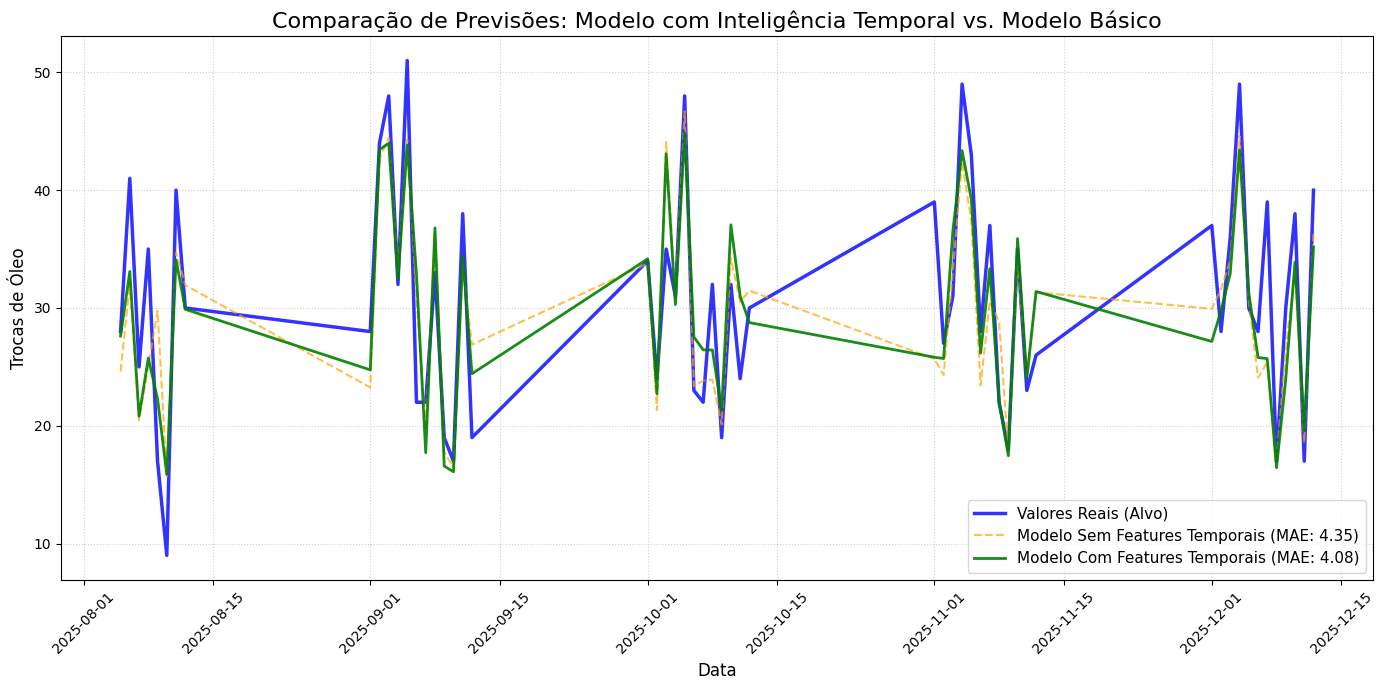

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Datas para o conjunto de teste com features (notando que removemos as 7 primeiras linhas do dataset total)
datas_teste_feat = df_features['Data'].iloc[split_feat:]

plt.plot(datas_teste_feat, y_test_feat, label='Valores Reais (Alvo)', color='blue', linewidth=2.5, alpha=0.8)
plt.plot(datas_teste_feat, y_pred_ts[-len(y_test_feat):], label=f'Modelo Sem Features Temporais (MAE: {mae_ts:.2f})', color='orange', linestyle='--', alpha=0.7)
plt.plot(datas_teste_feat, y_pred_feat, label=f'Modelo Com Features Temporais (MAE: {mae_feat:.2f})', color='green', linestyle='-', linewidth=2, alpha=0.9)

plt.title('Comparação de Previsões: Modelo com Inteligência Temporal vs. Modelo Básico', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Trocas de Óleo', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()